# Sentiment Analysis — Twitter RoBERTa

Fine-tuning `cardiffnlp/twitter-roberta-base-sentiment` on airline tweets.

**Labels:** `negative` · `neutral` · `positive`

**Train data:** `data/raw/train/{negative,neutral,positive}/*.txt` - one tweet per file  
**Test data:** `data/raw/test/*.tsv` - columns: `id`, `text`, `sentiment`, `topic`

Install Dependencies

In [1]:
%pip install torch transformers scikit-learn matplotlib seaborn numpy --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\louis\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Step 1: Configuration & Reproducibility

config file contains hyperparameters

In [2]:
import os
import re
import csv
import random
import numpy as np
from pathlib import Path
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

os.chdir(r"c:\Users\louis\Documents\tm-sentiment-analysis")
# hyperparams
CONFIG = {
    "train_dir":      "data/raw/train/airlinetweets",
    "ttest_dir": "data/raw",
    "results_dir":   "results",
    "model_name":    "cardiffnlp/twitter-roberta-base-sentiment",
    "max_length":    128, # max token length for twets
    "batch_size":    32,
    "epochs":        4,
    "learning_rate": 2e-5,
    "warmup_ratio":  0.1, # 10% of steps for LR
    "weight_decay":  0.01,
    "seed":          42,
    "num_workers":   0,
}

LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}
# experiment set up for reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
# device settings
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

os.makedirs(CONFIG["results_dir"], exist_ok=True)
print(f"Results will be saved to: {CONFIG['results_dir']}/")

C:\Users\louis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 2060
Results will be saved to: results/


## Step 2 - Data Loading & Exploration

- **Train:** reads every `.txt` file from `data/raw/train/{negative,neutral,positive}/`  
- **Test:** reads `.tsv` files from `data/raw/test/`, parses `text` + `sentiment` columns

In [3]:
def load_train(train_dir):
    """Load training tweets from per-label subdirectories of .txt files."""
    texts, labels = [], []
    train_path = Path(train_dir) 
    
    for label_name, label_id in LABEL2ID.items():
        label_dir = train_path / label_name
        if not label_dir.exists():
            raise FileNotFoundError(f"Expected directory not found: {label_dir}")
        for fp in sorted(label_dir.glob("*.txt")):
            tweet = fp.read_text(encoding="utf-8", errors="ignore").strip()
            if tweet:
                texts.append(tweet)
                labels.append(label_id)

    return texts, labels


def load_test(ttest_dir):
    """Load test data from TSV. Columns: id, text, sentiment, topic."""
    texts, labels = [], []
    test_dir = Path(ttest_dir) / "test"
    tsv_files = sorted(test_dir.glob("*.tsv"))
    if not tsv_files:
        raise FileNotFoundError(f"No .tsv files found in {test_dir}")

    for tsv_path in tsv_files:
        with open(tsv_path, encoding="utf-8", errors="ignore", newline="") as f:
            reader = csv.DictReader(f, delimiter="\t")
            for row in reader:
                sentiment = row["sentiment"].strip().lower()
                if sentiment not in LABEL2ID:
                    continue
                texts.append(row["text"].strip())
                labels.append(LABEL2ID[sentiment])

    return texts, labels


def explore_data(texts, labels, split_name):
    counts = Counter(labels)
    print(f"\n{'='*50}")
    print(f"  {split_name.upper()} SET  ({len(texts)} samples)")
    print(f"{'='*50}")
    for label_id, count in sorted(counts.items()):
        pct = 100 * count / len(labels)
        print(f"  {ID2LABEL[label_id]:<10}  {count:>5}  ({pct:.1f}%)")
    lengths = [len(t.split()) for t in texts]
    print(f"\n  Avg words: {np.mean(lengths):.1f}  |  Max: {max(lengths)}  |  Min: {min(lengths)}")
    print(f"\n  Sample tweets:")
    for label_id in [0, 1, 2]:
        idx = next(i for i, l in enumerate(labels) if l == label_id)
        print(f"  [{ID2LABEL[label_id]}] {texts[idx][:100]}...")


# Load
train_texts, train_labels = load_train(CONFIG["train_dir"])
test_texts,  test_labels  = load_test(CONFIG["ttest_dir"])

explore_data(train_texts, train_labels, "train")
explore_data(test_texts,  test_labels,  "test")


  TRAIN SET  (4755 samples)
  negative     1750  (36.8%)
  neutral      1515  (31.9%)
  positive     1490  (31.3%)

  Avg words: 14.0  |  Max: 32  |  Min: 1

  Sample tweets:
  [negative] @VirginAmerica my group got their Cancelled Flightlation fees waived but I can't because my ticket i...
  [neutral] @JetBlue's new CEO seeks the right balance to please passengers and Wall ... - Greenfield Daily Repo...
  [positive] @SouthwestAir nice work on the update!...

  TEST SET  (10 samples)
  negative        3  (30.0%)
  neutral         3  (30.0%)
  positive        4  (40.0%)

  Avg words: 19.5  |  Max: 29  |  Min: 14

  Sample tweets:
  [negative] It took eight years for Warner Brothers to recover from the disaster that was this movie....
  [neutral] The story of this movie is focused on Carl Brashear played by Cuba Gooding Jr. who wants to be the f...
  [positive] All the New York University students love this diner in Soho so it makes for a fun young atmosphere....


## Step 3 - Preprocessing

`twitter-roberta` was pretrained on raw tweets with `@user` and `http` as special tokens,  
normalise mentions and URLs to match format. The rest is unchanged

In [4]:
def clean_tweet(text):
    text = re.sub(r"@\w+", "@user", text)            
    text = re.sub(r"http\S+|www\.\S+", "http", text)
    return text.strip()

## Step 4 - PyTorch Dataset & DataLoaders

Tokenises all tweets upfront and stores the encoded tensors in memory.  

In [5]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.labels = labels
        self.encodings = tokenizer(
            [clean_tweet(t) for t in texts],
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }


print(f"Loading tokeniser: {CONFIG['model_name']}")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

print("Tokenising datasets...")
train_dataset = TweetDataset(train_texts, train_labels, tokenizer, CONFIG["max_length"])
test_dataset  = TweetDataset(test_texts,  test_labels,  tokenizer, CONFIG["max_length"])

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"],
                          shuffle=True,  num_workers=CONFIG["num_workers"], pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

print(f"Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}")

Loading tokeniser: cardiffnlp/twitter-roberta-base-sentiment


Tokenising datasets...
Train batches: 149  |  Test batches: 1


## Step 5 - Load Model

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {total_params:,} total  |  {trainable_params:,} trainable")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 22832.79it/s]


Parameters: 124,647,939 total  |  124,647,939 trainable


## Step 6 - Training

- **AdamW** optimiser with weight decay  
- **Linear LR warmup** for  first 10% of steps, then linear decay  
- **Mixed precision** (`autocast` + `GradScaler`) for faster GPU training  
- **Gradient clipping** (max norm 1.0) to prevent exploding gradients  
- Best checkpoint saved to `results/` whenever val accuracy improves

In [ ]:
print(next(model.parameters()).device)

def train_epoch(model, loader, optimizer, scheduler, scaler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        with autocast():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        correct    += (outputs.logits.argmax(dim=-1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        preds   = outputs.logits.argmax(dim=-1)

        total_loss += outputs.loss.item() * labels.size(0)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


# optimiszer and scheduler set up
total_steps  = len(train_loader) * CONFIG["epochs"]
warmup_steps = int(total_steps * CONFIG["warmup_ratio"])

optimizer = AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps=warmup_steps,
                                            num_training_steps=total_steps)
scaler = GradScaler()

print(f"Total steps: {total_steps}  |  Warmup steps: {warmup_steps}")
print(f"Epochs: {CONFIG['epochs']}  |  Batch size: {CONFIG['batch_size']}  |  LR: {CONFIG['learning_rate']}\n")

# training loop
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_acc = 0.0

for epoch in range(1, CONFIG["epochs"] + 1):
    tr_loss, tr_acc          = train_epoch(model, train_loader, optimizer, scheduler, scaler, device)
    va_loss, va_acc, _, _    = evaluate(model, test_loader, device)

    train_losses.append(tr_loss); val_losses.append(va_loss)
    train_accs.append(tr_acc);   val_accs.append(va_acc)

    print(f"Epoch {epoch}/{CONFIG['epochs']}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
          f"val_loss={va_loss:.4f}  val_acc={va_acc:.4f}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        model.save_pretrained(CONFIG["results_dir"])
        tokenizer.save_pretrained(CONFIG["results_dir"])
        print(f"New best model saved (val_acc={best_val_acc:.4f})")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

cuda:0
Total steps: 596  |  Warmup steps: 59
Epochs: 4  |  Batch size: 32  |  LR: 2e-05



C:\Users\louis\AppData\Local\Temp\ipykernel_1948\2176664866.py:62: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\louis\AppData\Local\Temp\ipykernel_1948\2176664866.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\louis\AppData\Local\Temp\ipykernel_1948\2176664866.py:22: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 1/4  train_loss=0.4141  train_acc=0.8381  val_loss=0.2961  val_acc=0.8000


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.08it/s]


  ✓ New best model saved (val_acc=0.8000)
Epoch 2/4  train_loss=0.2634  train_acc=0.9056  val_loss=0.2831  val_acc=0.8000
Epoch 3/4  train_loss=0.1857  train_acc=0.9375  val_loss=0.4463  val_acc=0.8000
Epoch 4/4  train_loss=0.1338  train_acc=0.9548  val_loss=0.5701  val_acc=0.8000

Best val accuracy: 0.8000


## Step 7 - Evaluation & Plots

Full classification report on test set,  
$+$ training curves and roc

In [8]:
# classification report
_, _, all_preds, all_labels = evaluate(model, test_loader, device)
label_names = [ID2LABEL[i] for i in range(3)]
print(classification_report(all_labels, all_preds, target_names=label_names))

              precision    recall  f1-score   support

    negative       1.00      0.67      0.80         3
     neutral       0.75      1.00      0.86         3
    positive       0.75      0.75      0.75         4

    accuracy                           0.80        10
   macro avg       0.83      0.81      0.80        10
weighted avg       0.82      0.80      0.80        10



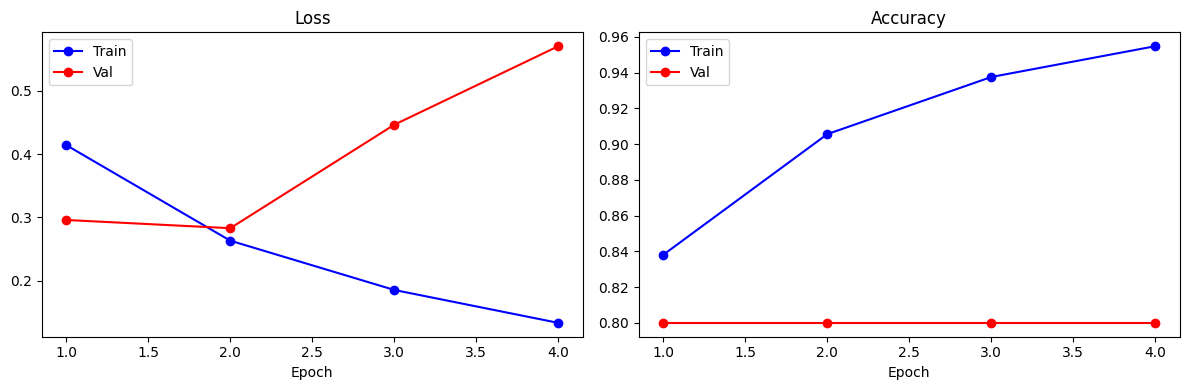

In [9]:
# curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(train_losses) + 1)

ax1.plot(epochs, train_losses, "b-o", label="Train")
ax1.plot(epochs, val_losses,   "r-o", label="Val")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(epochs, train_accs, "b-o", label="Train")
ax2.plot(epochs, val_accs,   "r-o", label="Val")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.savefig(Path(CONFIG["results_dir"]) / "training_curves.png", dpi=150)
plt.show()

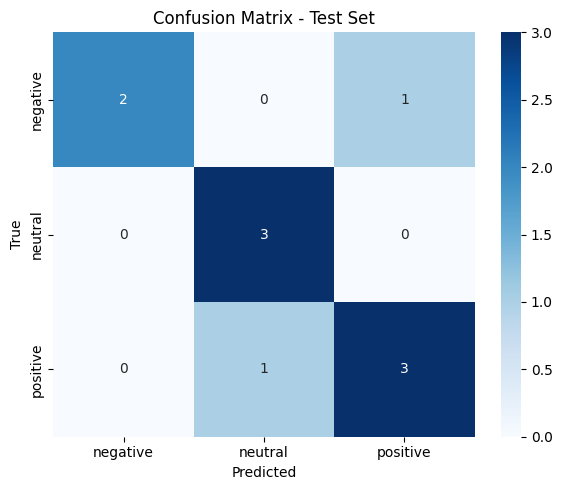


 Model + plots saved to: results/ 


In [11]:
# conf matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.savefig(Path(CONFIG["results_dir"]) / "confusion_matrix.png", dpi=150)
plt.show()

print(f"\n Model + plots saved to: {CONFIG['results_dir']}/ ")